# TimeGNN - Oil Market Forecasting

Mô phỏng thuật toán **TimeGNN** (Time-series Graph Neural Network) để dự báo giá dầu từ dữ liệu `oil_market_GNN.csv`.

## Pipeline:
1. Load & tiền xử lý dữ liệu
2. Xây dựng đồ thị tương quan (Correlation-based Graph)
3. Xây dựng mô hình TimeGNN (GCN + GRU)
4. Huấn luyện với sliding window
5. Đánh giá: MAE, RMSE, MAPE, R²

In [ ]:
# Chạy local thì khỏi chạy đoạn này nhé!
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Cài thư viện nếu cần ──
import subprocess, sys
pkgs = ["torch", "torch-geometric", "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn"]
for p in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])
print("Done")

Done


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

plt.rcParams['figure.dpi'] = 120
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


## 1. Load & Tiền xử lý dữ liệu

In [ ]:
# ── Load dữ liệu ──
# Thay link data local vào nhé
df = pd.read_csv('/content/drive/MyDrive/HMCN/TimeGNN_Oil/oil_market_GNN.csv')
df['Ngày'] = pd.to_datetime(df['Ngày'])
df = df.sort_values('Ngày').reset_index(drop=True)

# Làm sạch: thay dấu phẩy thập phân sang dấu chấm
str_cols = df.select_dtypes(include='object').columns.tolist()
str_cols = [c for c in str_cols if c not in ['Ngày']]
for c in str_cols:
    df[c] = df[c].astype(str).str.replace(',', '.', regex=False)
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Chọn các features chính (nodes)
FEATURES = ['MG95', 'MG92', 'DO 0.001%', 'DO 0.05%',
            'BRT DTD', 'BRT KH', 'WTI',
            'USD_Index', 'GPRD']
TARGET = 'MG95'

df = df[['Ngày'] + FEATURES].dropna().reset_index(drop=True)
print("Shape:", df.shape)
print("Date range:", df['Ngày'].min(), "->", df['Ngày'].max())
df[FEATURES].describe().round(2)

Shape: (4610, 10)
Date range: 2008-05-02 00:00:00 -> 2026-03-18 00:00:00


,MG95,MG92,DO 0.001%,DO 0.05%,BRT DTD,BRT KH,WTI,USD_Index,GPRD
count,4610.00,4610.00,4610.00,4610.00,4610.00,4610.00,4610.00,4610.00,4610.00
mean,88.31,85.49,93.27,91.77,77.43,77.62,72.03,107.71,112.80
std,25.58,25.22,29.66,29.15,24.59,23.95,21.77,12.29,52.24
min,16.12,14.64,22.92,20.75,13.24,19.15,9.47,85.47,9.49
25%,70.61,67.74,72.69,71.38,60.20,60.50,54.69,93.95,78.87
50%,84.16,81.51,88.12,87.10,74.62,74.82,71.22,111.78,102.75
75%,109.36,106.39,119.56,118.00,98.17,97.87,88.25,117.53,135.63
max,160.86,155.72,198.88,197.88,144.22,146.60,145.31,130.21,564.93


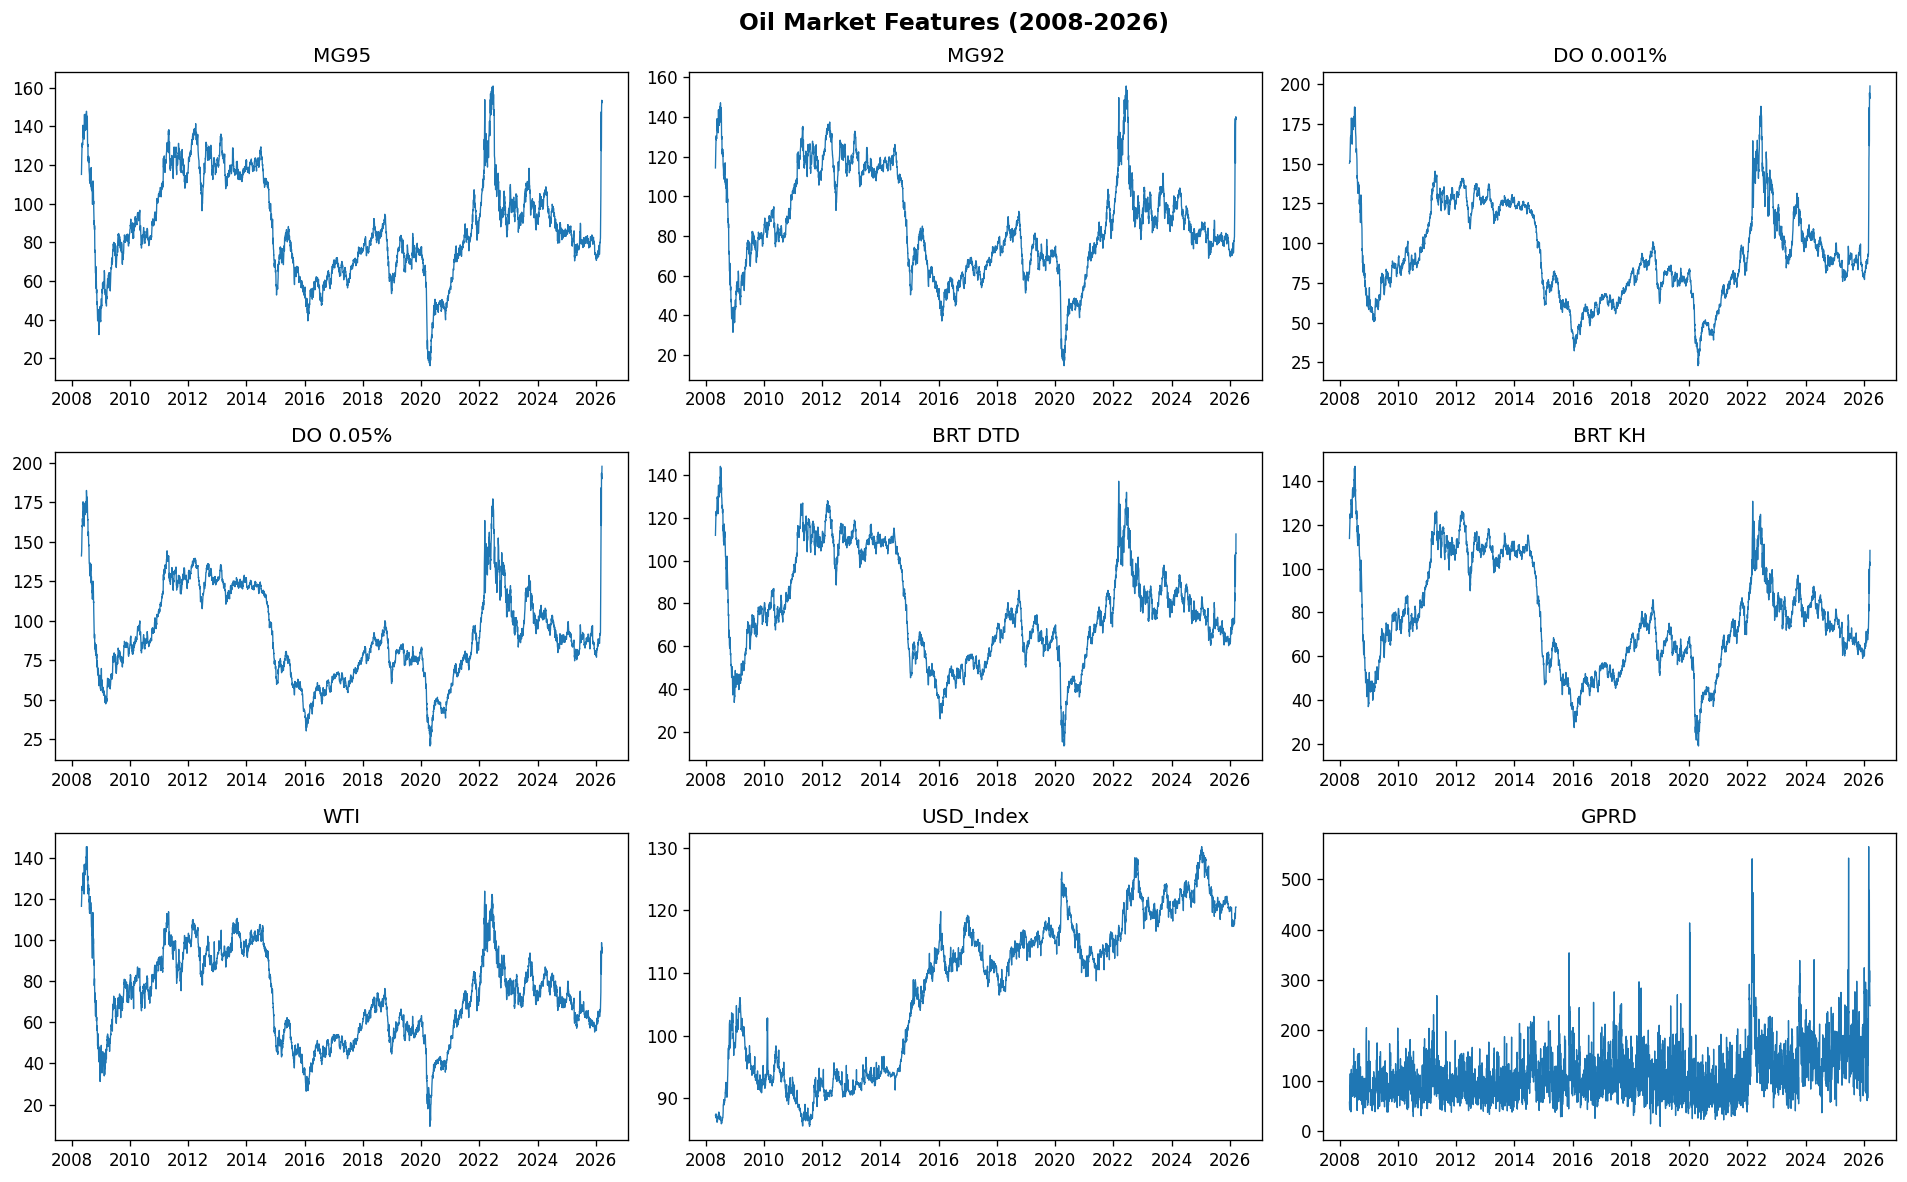

In [ ]:
# ── Visualize target ──
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), FEATURES):
    ax.plot(df['Ngày'], df[col], linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Oil Market Features (2008-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Chuẩn hóa ──
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[FEATURES])
data_scaled = pd.DataFrame(data_scaled, columns=FEATURES)

# Lưu scaler target riêng để inverse_transform kết quả
target_idx = FEATURES.index(TARGET)
scaler_target = MinMaxScaler()
scaler_target.fit(df[[TARGET]])
print("Scaled shape:", data_scaled.shape)

Scaled shape: (4610, 9)


## 2. Xây dựng Graph (Correlation-based)

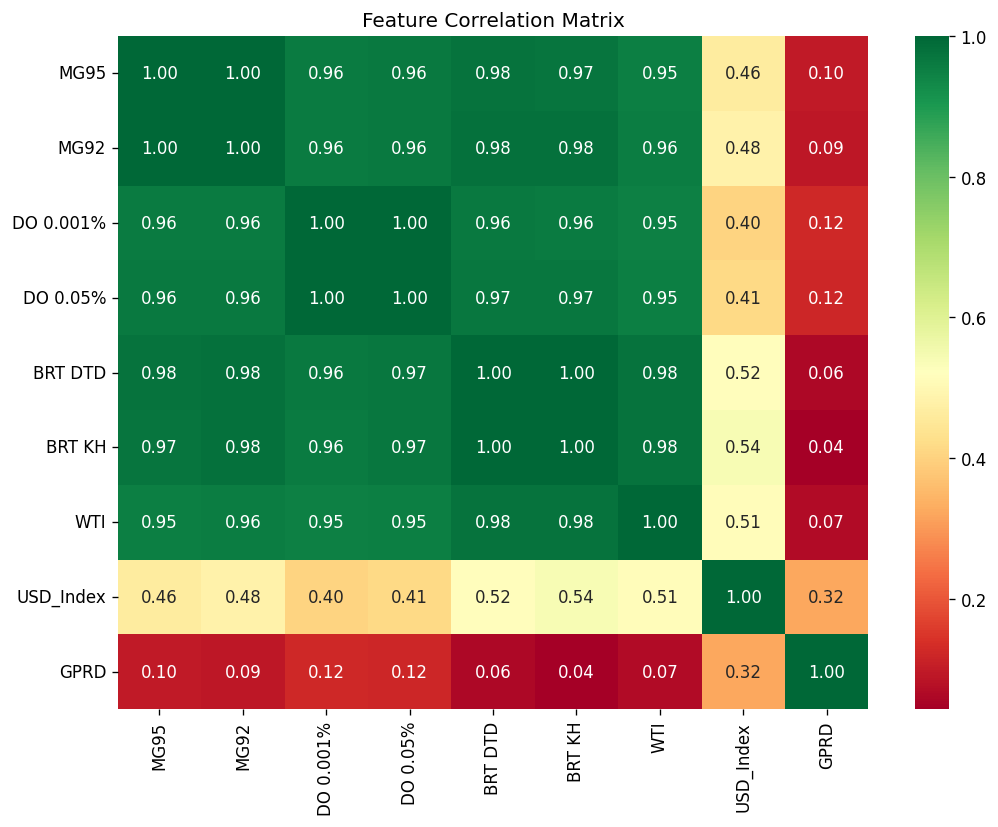

Nodes: 9  |  Edges: 42
Edge list: [('MG95', 'MG92'), ('MG95', 'DO 0.001%'), ('MG95', 'DO 0.05%'), ('MG95', 'BRT DTD'), ('MG95', 'BRT KH'), ('MG95', 'WTI')] ...


In [ ]:
# ── Xây dựng đồ thị tương quan giữa các biến ──
# Nodes = các features (MG95, WTI, BRT,...)
# Edges = cặp (i,j) có |corr| > threshold

CORR_THRESHOLD = 0.6

corr_matrix = df[FEATURES].corr().abs()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=FEATURES, yticklabels=FEATURES)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Xây dựng edge_index từ correlation
edge_src, edge_dst = [], []
num_nodes = len(FEATURES)
for i in range(num_nodes):
    for j in range(num_nodes):
        if i != j and corr_matrix.iloc[i, j] >= CORR_THRESHOLD:
            edge_src.append(i)
            edge_dst.append(j)

edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
print(f"Nodes: {num_nodes}  |  Edges: {edge_index.shape[1]}")
print("Edge list:", list(zip([FEATURES[s] for s in edge_src[:6]],
                              [FEATURES[d] for d in edge_dst[:6]])), "...")

## 3. Tạo Dataset (Sliding Window)

In [ ]:
# ── Sliding Window ──
# Mỗi sample: X = (window_size, num_nodes, 1) -> y = giá MG95 bước tiếp theo

WINDOW = 20    # look-back window
HORIZON = 1    # dự báo 1 bước

def make_sequences(data, window, horizon, target_col):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i : i + window].values)          # (W, F)
        y.append(data[target_col].iloc[i + window + horizon - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = make_sequences(data_scaled, WINDOW, HORIZON, TARGET)
print("X_all:", X_all.shape, " | y_all:", y_all.shape)

# Train / Val / Test split: 70/15/15
n = len(X_all)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:], y_all[n_train+n_val:]

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

X_all: (4590, 20, 9)  | y_all: (4590,)
Train: 3213  Val: 688  Test: 689


## 4. Mô hình TimeGNN

**Kiến trúc:**
```
[Input: (batch, window, num_nodes, 1)]
    -> GCNConv (mỗi time-step)    # học tương quan không gian
    -> GRU                          # học tương quan thời gian
    -> Linear -> output
```

In [ ]:
class TimeGNN(nn.Module):
    def __init__(self, num_nodes, gcn_hidden, gru_hidden, gru_layers=2, dropout=0.2):
        super().__init__()
        self.num_nodes  = num_nodes
        self.gcn_hidden = gcn_hidden
        self.gru_hidden = gru_hidden

        # GCN cho từng time-step
        self.gcn1 = GCNConv(1, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)

        # GRU học temporal
        self.gru = nn.GRU(
            input_size  = num_nodes * gcn_hidden,
            hidden_size = gru_hidden,
            num_layers  = gru_layers,
            batch_first = True,
            dropout     = dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(gru_hidden, 1)

    def forward(self, x, edge_index):
        # x: (B, W, N)  edge_index: (2, E)
        B, W, N = x.shape
        gcn_out = []
        for t in range(W):
            xt = x[:, t, :]          # (B, N)
            xt = xt.reshape(B * N, 1) # node features
            # expand edge_index for batch
            ei = edge_index
            # GCN forward (dùng batch trick đơn giản)
            h = F.relu(self.gcn1(xt, ei))
            h = F.relu(self.gcn2(h, ei))   # (B*N, gcn_hidden)
            h = h.reshape(B, N * self.gcn_hidden)  # (B, N*gcn_hidden)
            gcn_out.append(h)

        # (B, W, N*gcn_hidden)
        gcn_seq = torch.stack(gcn_out, dim=1)
        gcn_seq = self.dropout(gcn_seq)

        gru_out, _ = self.gru(gcn_seq)   # (B, W, gru_hidden)
        last = gru_out[:, -1, :]          # (B, gru_hidden)
        out = self.fc(last).squeeze(-1)   # (B,)
        return out

# --- Quick test ---
model_test = TimeGNN(num_nodes=len(FEATURES), gcn_hidden=32, gru_hidden=64)
xd = torch.randn(4, WINDOW, len(FEATURES))
ei = torch.zeros(2, 0, dtype=torch.long)
print("Output shape:", model_test(xd, ei).shape)
print("Parameters:", sum(p.numel() for p in model_test.parameters()))

Output shape: torch.Size([4])
Parameters: 94113


In [ ]:
# ── DataLoader ──
from torch.utils.data import DataLoader, TensorDataset

def make_loader(X, y, batch_size=64, shuffle=False):
    tx = torch.tensor(X)          # (N, W, F)
    ty = torch.tensor(y)
    return DataLoader(TensorDataset(tx, ty), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   batch_size=64)
test_loader  = make_loader(X_test,  y_test,  batch_size=64)

print("Loaders ready")

Loaders ready


## 5. Huấn luyện

In [ ]:
# ── Hyperparameters ──
GCN_HIDDEN  = 32
GRU_HIDDEN  = 64
GRU_LAYERS  = 2
DROPOUT     = 0.2
LR          = 1e-3
EPOCHS      = 80
PATIENCE    = 15

model = TimeGNN(len(FEATURES), GCN_HIDDEN, GRU_HIDDEN, GRU_LAYERS, DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.HuberLoss()

ei = edge_index.to(device)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, count = 0., 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb, ei)
            loss = criterion(pred, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(yb)
            count += len(yb)
    return total_loss / count

train_losses, val_losses = [], []
best_val, best_state, wait = 1e9, None, 0

for epoch in range(1, EPOCHS + 1):
    tl = run_epoch(train_loader, True)
    vl = run_epoch(val_loader,   False)
    scheduler.step(vl)
    train_losses.append(tl); val_losses.append(vl)

    if vl < best_val:
        best_val, best_state, wait = vl, model.state_dict(), 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stop at epoch {epoch}"); break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train: {tl:.5f} | Val: {vl:.5f}")

model.load_state_dict(best_state)
print("\nBest val loss:", best_val)

Epoch  10 | Train: 0.00042 | Val: 0.00066
Epoch  20 | Train: 0.00041 | Val: 0.00082
Epoch  30 | Train: 0.00035 | Val: 0.00056
Epoch  40 | Train: 0.00033 | Val: 0.00063
Early stop at epoch 47

Best val loss: 0.0004873106531598497


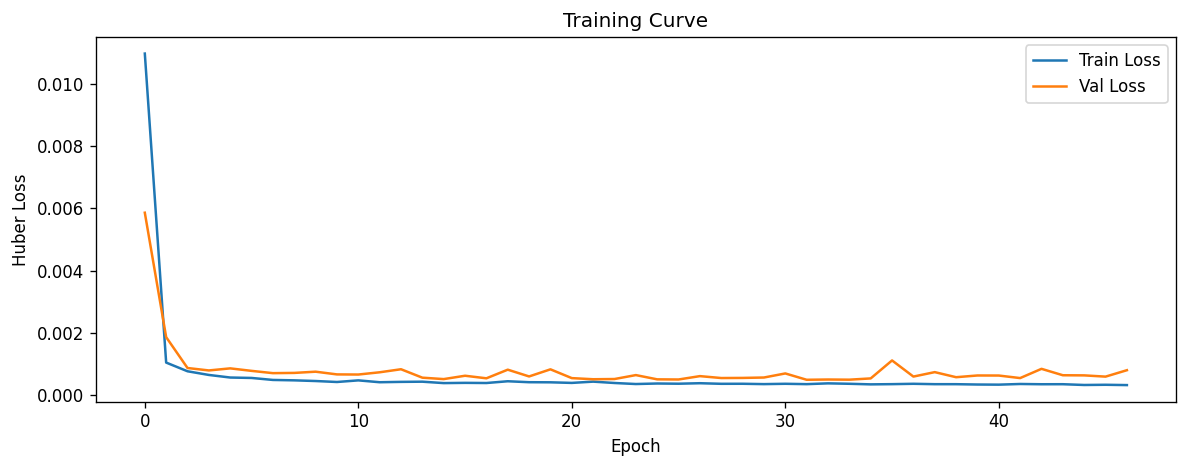

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss')
plt.title('Training Curve'); plt.legend(); plt.tight_layout(); plt.show()

## 6. Đánh giá

In [ ]:
def predict_all(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            p = model(xb.to(device), ei).cpu().numpy()
            preds.extend(p); trues.extend(yb.numpy())
    return np.array(preds), np.array(trues)

p_test, t_test = predict_all(test_loader)

# Inverse transform
p_inv = scaler_target.inverse_transform(p_test.reshape(-1,1)).flatten()
t_inv = scaler_target.inverse_transform(t_test.reshape(-1,1)).flatten()

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mae  = mean_absolute_error(t_inv, p_inv)
rmse = np.sqrt(mean_squared_error(t_inv, p_inv))
mape_val = mape(t_inv, p_inv)
r2   = r2_score(t_inv, p_inv)

print("=" * 40)
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAPE : {mape_val:.2f}%")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

  MAE  : 3.6054
  RMSE : 5.2104
  MAPE : 3.78%
  R²   : 0.8152


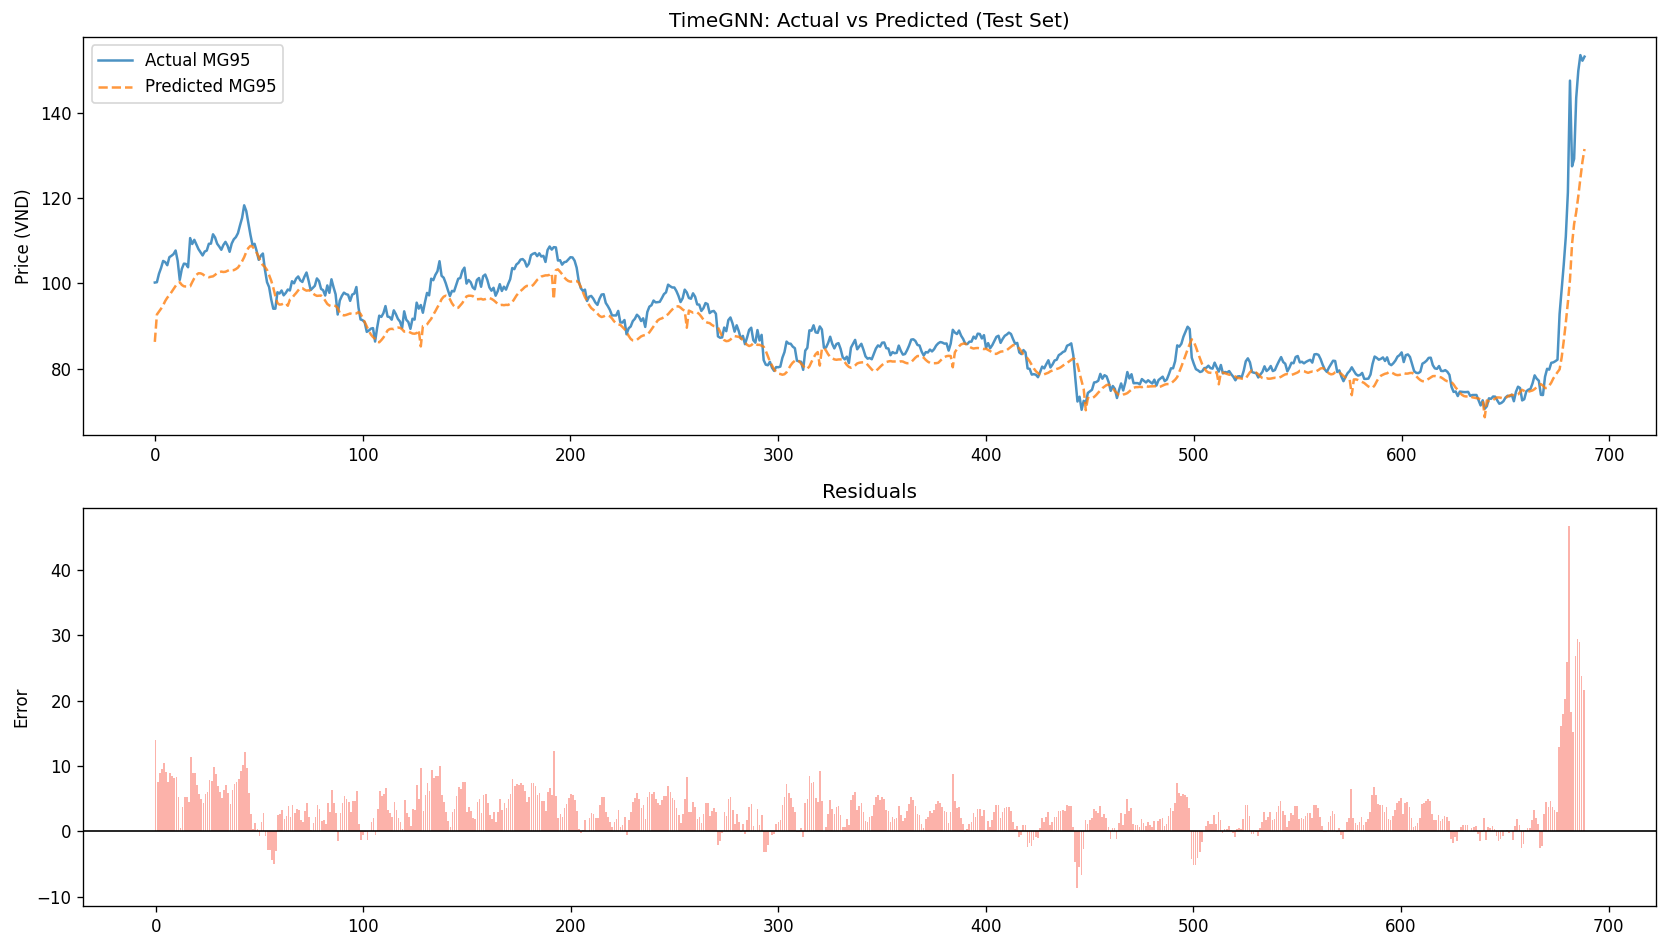

  Metric    Value
     MAE 3.605410
    RMSE 5.210403
MAPE (%) 3.779092
      R² 0.815161


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: True vs Predicted
axes[0].plot(t_inv, label='Actual MG95', alpha=0.8)
axes[0].plot(p_inv, label='Predicted MG95', alpha=0.8, linestyle='--')
axes[0].set_title('TimeGNN: Actual vs Predicted (Test Set)')
axes[0].legend(); axes[0].set_ylabel('Price (VND)')

# Plot 2: Residuals
resid = t_inv - p_inv
axes[1].bar(range(len(resid)), resid, alpha=0.6, color='salmon')
axes[1].axhline(0, color='k', linewidth=1)
axes[1].set_title('Residuals'); axes[1].set_ylabel('Error')

plt.tight_layout(); plt.show()

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R²'],
    'Value':  [mae, rmse, mape_val, r2]
})
print(metrics_df.to_string(index=False))

## 7. So sánh các Horizon dự báo (1, 5, 10 ngày)

In [ ]:
results = {}
for horizon in [1, 5, 10]:
    Xh, yh = make_sequences(data_scaled, WINDOW, horizon, TARGET)
    n_h = len(Xh)
    split = int(n_h * 0.85)
    Xte = torch.tensor(Xh[split:])
    yte = yh[split:]

    # Tạo model riêng cho từng horizon
    mh = TimeGNN(len(FEATURES), GCN_HIDDEN, GRU_HIDDEN, GRU_LAYERS, DROPOUT).to(device)
    opt_h = torch.optim.Adam(mh.parameters(), lr=LR, weight_decay=1e-4)
    dl_tr = DataLoader(TensorDataset(
        torch.tensor(Xh[:split]), torch.tensor(yh[:split])), batch_size=64, shuffle=True)

    mh.train()
    for ep in range(50):
        for xb, yb in dl_tr:
            opt_h.zero_grad()
            loss = criterion(mh(xb.to(device), ei), yb.to(device))
            loss.backward(); opt_h.step()

    mh.eval()
    with torch.no_grad():
        ph = mh(Xte.to(device), ei).cpu().numpy()

    pi = scaler_target.inverse_transform(ph.reshape(-1,1)).flatten()
    ti = scaler_target.inverse_transform(yte.reshape(-1,1)).flatten()

    results[horizon] = {
        'MAE':  mean_absolute_error(ti, pi),
        'RMSE': np.sqrt(mean_squared_error(ti, pi)),
        'MAPE': mape(ti, pi),
        'R²':   r2_score(ti, pi)
    }
    print(f"Horizon {horizon:2d} | MAE={results[horizon]['MAE']:.3f} | "
          f"RMSE={results[horizon]['RMSE']:.3f} | "
          f"MAPE={results[horizon]['MAPE']:.2f}% | "
          f"R²={results[horizon]['R²']:.4f}")

res_df = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Horizon'})
print("\n", res_df.round(4).to_string(index=False))

Horizon  1 | MAE=2.598 | RMSE=3.822 | MAPE=2.90% | R²=0.9005
Horizon  5 | MAE=5.010 | RMSE=7.518 | MAPE=5.24% | R²=0.6153
Horizon 10 | MAE=4.581 | RMSE=8.607 | MAPE=4.70% | R²=0.4958

  Horizon    MAE   RMSE   MAPE     R²
       1 2.5984 3.8220 2.8986 0.9005
       5 5.0105 7.5185 5.2384 0.6153
      10 4.5812 8.6071 4.7007 0.4958


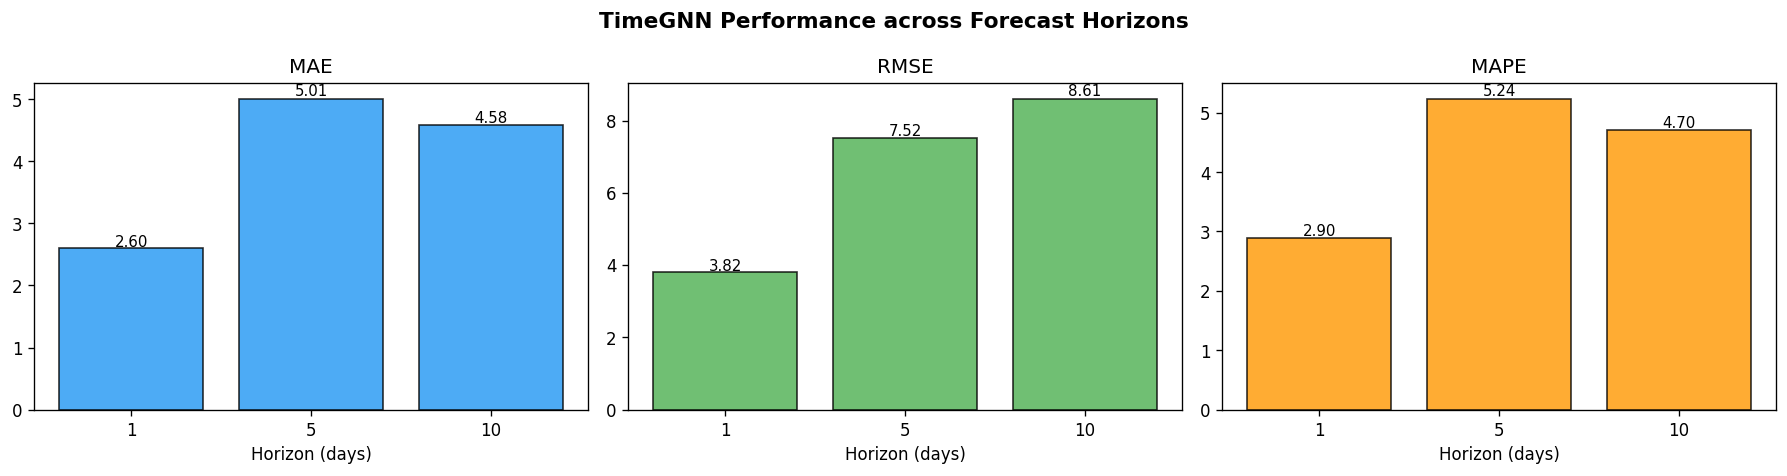

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['MAE', 'RMSE', 'MAPE']
horizons = list(results.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, metric, color in zip(axes, metrics, colors):
    vals = [results[h][metric] for h in horizons]
    ax.bar([str(h) for h in horizons], vals, color=color, alpha=0.8, edgecolor='black')
    ax.set_title(metric); ax.set_xlabel('Horizon (days)')
    for i, v in enumerate(vals):
        ax.text(i, v * 1.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('TimeGNN Performance across Forecast Horizons', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Lưu mô hình & Kết luận

In [ ]:
import os
torch.save({
    'model_state': model.state_dict(),
    'scaler_target': scaler_target,
    'scaler': scaler,
    'features': FEATURES,
    'window': WINDOW,
    'edge_index': edge_index,
    'metrics': results
}, 'timegnn_oil.pth')
print("Model saved to timegnn_oil.pth")

print("\n=== KẾT QUẢ TỔNG HỢP ===")
print(f"MAE  (1-step): {mae:.4f} VND")
print(f"RMSE (1-step): {rmse:.4f} VND")
print(f"MAPE (1-step): {mape_val:.2f}%")
print(f"R²   (1-step): {r2:.4f}")
print("\nTimeGNN sử dụng GCN để học tương quan không gian giữa")
print("các thị trường dầu và GRU để học xu hướng thời gian.")

Model saved to timegnn_oil.pth

=== KẾT QUẢ TỔNG HỢP ===
MAE  (1-step): 3.6054 VND
RMSE (1-step): 5.2104 VND
MAPE (1-step): 3.78%
R²   (1-step): 0.8152

TimeGNN sử dụng GCN để học tương quan không gian giữa
các thị trường dầu và GRU để học xu hướng thời gian.
